In [1]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import random
import math
import pickle
import os
import ast
import psutil
from scipy.spatial import Delaunay
import statistics
from collections import Counter
from statistics import mode
import seaborn as sns
from mpl_toolkits import mplot3d
from tqdm import tqdm
from scipy.stats import multivariate_hypergeom
from scipy import stats
from termcolor import colored, cprint
from scipy.optimize import curve_fit
from sympy import Symbol, Integral
from PIL import Image
from openpyxl import Workbook
from itertools import combinations
import plotly.graph_objects as go
from scipy.spatial import ConvexHull
from pathlib import Path


wb=Workbook()
ws=wb.active
np.set_printoptions(threshold=np.inf) 



In [3]:
def np_array_to_tuple(np_array_algebra):
    to_list_info=np_array_algebra.tolist()
    converted_matrix=tuple(tuple(tuple(x) for x in sublist) for sublist in to_list_info)

    return converted_matrix
    
def tuple_to_np_array(tuple_algebra):
    new_algebra_of_interest = []
    for inner in tuple_algebra:
        inner_list = []
        for x in inner:
            inner_list.append(list(x))
        new_algebra_of_interest.append(inner_list)

    new_algebra_of_interest=np.array(new_algebra_of_interest)

    return new_algebra_of_interest


def matrix_maker(matrix, index_array, value_array):
    matrix_new = copy.deepcopy(matrix)  # NumPy-safe copy
    for ind, val in zip(index_array, value_array):
        matrix_new[tuple(ind)] = val  # convert to tuple for proper indexing
    return matrix_new

In [4]:
def matrix_to_3d(matrix, difference_points1, difference_points2):
    depth, rows, cols = matrix.shape
    cmatrix=copy.deepcopy(matrix)
    stacked_matrix=np.array([])
    stacked_points=np.array([])
    for x in range(depth):
        temp_x_matrix=np.array(matrix_emptier(cmatrix[x,:,:]))
        temp_x_points=point_orderer(temp_x_matrix)
        stacked_matrix, stacked_points= three_dim_maker(stacked_matrix, stacked_points, temp_x_matrix, temp_x_points, x)

    three_dim_drawer(stacked_matrix, stacked_points, difference_points1, difference_points2)

def matrix_emptier(matrix):

    rows, cols= matrix.shape
    for i in range(rows):
        ones_indices = np.where(matrix[i] == 1)[0]
        for j in range(cols):
            if len(ones_indices) >= 2:
    # Keep only the first and last
                first = ones_indices[0]
                last = ones_indices[-1]

    # Set all 1s to 0 first
                matrix[i][matrix[i][j] == 1] = 0

    # Set only first and last 1s back to 1
                matrix[i][first] = 1
                matrix[i][last] = 1
    
    return matrix

def point_orderer(matrix):
    points = np.argwhere(matrix == 1)
    len_points=len(points)
    copy_points=copy.deepcopy(points)

    temp_points_array=[]

    for i in range(int(len(points)/2)):
        temp_points_array.append(points[2*i+1])
    temp_points_array=np.array(temp_points_array)
    copy_points=np.array(copy_points)
    temp_points_array=temp_points_array.tolist()
    copy_points=copy_points.tolist()


    for row in copy_points:
        if row in temp_points_array:
            copy_points.remove(row)

    first_half_points = copy_points
    second_half_points = temp_points_array

    for i in range(len(second_half_points)):
        first_half_points.append(second_half_points[int(len(points)/2)-(i+1)])

    new_points= np.array(first_half_points)
    #print("new_points",new_points)
    return new_points


def three_dim_maker(stacked_matrix, stacked_points, matrix, points, x): #stack in x direction
    matrix=matrix.tolist()
    stacked_matrix=stacked_matrix.tolist()
    stacked_matrix.append(matrix)

    new_points=[]
    points=points.tolist()
    for el in points:
        #print("el",el)
        new_points.append([x]+el)
        
    #print(x,new_points)
    stacked_points=stacked_points.tolist()
    stacked_points+=new_points
    return np.array(stacked_matrix), np.array(stacked_points)



def tuple_to_np_array(tuple_algebra):
    new_algebra_of_interest = []
        #print("algebra_of_interest",algebra_of_interest)
    for inner in tuple_algebra:
        inner_list = []
        for x in inner:
            inner_list.append(list(x))
        new_algebra_of_interest.append(inner_list)

        #print("new_algebra_of_interest",new_algebra_of_interest)
    new_algebra_of_interest=np.array(new_algebra_of_interest)

    return new_algebra_of_interest

In [5]:
def three_dim_drawer(matrix, points, difference_points1, difference_points2):

    # Dimensions
    depth, rows, cols = matrix.shape
    points = np.array(points)
    x, y, z = points[:, 0], points[:, 1], points[:, 2]

    # --- Original BLUE perimeter lines (x-plane) ---
    point_x_dict = {}
    for x_val in range(depth):
        k = 0
        for point_el in points:
            if point_el[0] == x_val:
                k += 1
        if x_val == 0:
            point_x_dict[x_val] = k
        else:
            point_x_dict[x_val] = k + point_x_dict[x_val - 1]

    edge_traces = []
    for el1 in range(depth):
        if el1 == 0:
            for elem1 in range(0, point_x_dict[0] - 1):
                edge_traces.append((elem1, elem1 + 1))
                edge_traces.append((0, point_x_dict[0] - 1))
        else:
            for elem1 in range(point_x_dict[el1 - 1], point_x_dict[el1] - 1):
                edge_traces.append((elem1, elem1 + 1))
                edge_traces.append((point_x_dict[el1 - 1], point_x_dict[el1] - 1))

    edge_traces_3d = []
    for start, end in edge_traces:
        edge_traces_3d.append(go.Scatter3d(
            x=[x[start], x[end]],
            y=[y[start], y[end]],
            z=[z[start], z[end]],
            mode='lines',
            line=dict(color='blue', width=3),
            showlegend=False
        ))

    # --- BLUE hull lines (y-plane) ---
    blue_hull_traces = []
    unique_y = np.unique(y)
    for y_val in unique_y:
        mask = y == y_val
        slice_points = np.column_stack((x[mask], y[mask], z[mask]))

        if len(slice_points) >= 3:
            xz_points = slice_points[:, [0, 2]]
            try:
                hull = ConvexHull(xz_points)
                hull_indices = hull.vertices
                hull_loop = np.append(hull_indices, hull_indices[0])  # close loop

                for i in range(len(hull_loop) - 1):
                    i1, i2 = hull_loop[i], hull_loop[i + 1]
                    blue_hull_traces.append(go.Scatter3d(
                        x=[slice_points[i1, 0], slice_points[i2, 0]],
                        y=[slice_points[i1, 1], slice_points[i2, 1]],
                        z=[slice_points[i1, 2], slice_points[i2, 2]],
                        mode='lines',
                        line=dict(color='blue', width=3),
                        showlegend=False
                    ))
            except:
                pass

    # --- RED difference points ---
    red_traces = []
    if difference_points1 is not None and len(difference_points1) > 0:
        difference_points1 = np.array(difference_points1)
        diff_x1, diff_y1, diff_z1 = (
            difference_points1[:, 0],
            difference_points1[:, 1],
            difference_points1[:, 2],
        )

        red_traces = [go.Scatter3d(
            x=diff_x1,
            y=diff_y1,
            z=diff_z1,
            mode='markers',
            marker=dict(size=2, color='red', symbol='circle'),
            text=[f"Diff1-{i}" for i in range(len(diff_x1))],
            textposition="top center",
            name="Difference Set 1"
        )]

    # --- GREEN difference points ---
    green_traces = []
    if difference_points2 is not None and len(difference_points2) > 0:
        difference_points2 = np.array(difference_points2)
        diff_x2, diff_y2, diff_z2 = (
            difference_points2[:, 0],
            difference_points2[:, 1],
            difference_points2[:, 2],
        )

        # ✔ FIXED: now correctly stored in green_traces 
        green_traces = [go.Scatter3d(
            x=diff_x2,
            y=diff_y2,
            z=diff_z2,
            mode='markers',
            marker=dict(size=2, color='green', symbol='circle'),
            text=[f"Diff2-{i}" for i in range(len(diff_x2))],
            textposition="top center",
            name="Difference Set 2"
        )]

    # --- Original vertex markers ---
    vertex_trace = go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(size=2, color='blue'),
        text=[f"P{i}" for i in range(len(x))],
        textposition="top center",
        name='Vertices'
    )

    # ---- FIXED AXIS SCALE ----
    fig = go.Figure(
        data=[vertex_trace] +
             edge_traces_3d +
             blue_hull_traces +
             red_traces +
             green_traces
    )

    fig.update_layout(
        title="3D Shape with Blue hull lines and Difference Points",
        scene=dict(
            xaxis=dict(title='X', range=[0, depth]),
            yaxis=dict(title='Y', range=[0, rows]),
            zaxis=dict(title='Z', range=[0, cols]),

            aspectmode='manual',
            aspectratio=dict(
                x=depth,
                y=rows * 1.3,
                z=cols * 1.4
            ),

            camera=dict(
                eye=dict(x=25, y=25, z=25)
            )
        ),
        width=800,
        height=800
    )

    fig.show()


In [6]:
def matrix_emptier_for_inner(matrix):
    rows, cols = matrix.shape
    interior_points = []  # NEW: collect stripped points
    for i in range(rows):
        ones_indices = np.where(matrix[i] == 1)[0]
        for j in range(cols):
            if len(ones_indices) >= 2:
                first = ones_indices[0]
                last = ones_indices[-1]
                # NEW: collect interior points (everything between first and last)
                for idx in ones_indices:
                    if idx != first and idx != last:
                        interior_points.append([i, idx])
                matrix[i][matrix[i][j] == 1] = 0
                matrix[i][first] = 1
                matrix[i][last] = 1
    return matrix, interior_points  # NEW: return interior points too


def point_orderer_for_inner(matrix):
    points = np.argwhere(matrix == 1)
    len_points = len(points)
    copy_points = copy.deepcopy(points)
    temp_points_array = []
    for i in range(int(len(points) / 2)):
        temp_points_array.append(points[2 * i + 1])
    temp_points_array = np.array(temp_points_array)
    copy_points = np.array(copy_points)
    temp_points_array = temp_points_array.tolist()
    copy_points = copy_points.tolist()
    for row in copy_points:
        if row in temp_points_array:
            copy_points.remove(row)
    first_half_points = copy_points
    second_half_points = temp_points_array
    for i in range(len(second_half_points)):
        first_half_points.append(second_half_points[int(len(points) / 2) - (i + 1)])
    new_points = np.array(first_half_points)
    return new_points


def three_dim_maker_for_inner(stacked_matrix, stacked_points, matrix, points, x):
    matrix = matrix.tolist()
    stacked_matrix = stacked_matrix.tolist()
    stacked_matrix.append(matrix)
    new_points = []
    points = points.tolist()
    for el in points:
        new_points.append([x] + el)
    stacked_points = stacked_points.tolist()
    stacked_points += new_points
    return np.array(stacked_matrix), np.array(stacked_points)


def three_dim_maker_interior(stacked_interior, interior_points, x):
   
    stacked_interior = stacked_interior.tolist()
    for el in interior_points:
        stacked_interior.append([x] + el)
    return np.array(stacked_interior)


def matrix_to_3d_for_inner_rep(matrix, difference_points1, difference_points2):
    depth, rows, cols = matrix.shape
    cmatrix = copy.deepcopy(matrix)
    stacked_matrix = np.array([])
    stacked_points = np.array([])
    stacked_interior = np.array([])

    for x in range(depth):
        temp_x_matrix, interior_points = matrix_emptier_for_inner(cmatrix[x, :, :])
        temp_x_points = point_orderer_for_inner(temp_x_matrix)
        stacked_matrix, stacked_points = three_dim_maker_for_inner(
            stacked_matrix, stacked_points, temp_x_matrix, temp_x_points, x
        )
        if len(interior_points) > 0:
            stacked_interior = three_dim_maker_interior(stacked_interior, interior_points, x)

    interior_list = stacked_interior.tolist() if len(stacked_interior) > 0 else None

    # Pass interior separately, keep difference_points2 untouched
    three_dim_drawer_for_inner_rep(stacked_matrix, stacked_points, difference_points1, difference_points2, interior_list)

def three_dim_drawer_for_inner_rep(matrix, points, difference_points1, difference_points2, interior_points=None):

    depth, rows, cols = matrix.shape
    points = np.array(points)
    x, y, z = points[:, 0], points[:, 1], points[:, 2]

    # --- Original BLUE perimeter lines (x-plane) ---
    point_x_dict = {}
    for x_val in range(depth):
        k = 0
        for point_el in points:
            if point_el[0] == x_val:
                k += 1
        if x_val == 0:
            point_x_dict[x_val] = k
        else:
            point_x_dict[x_val] = k + point_x_dict[x_val - 1]

    edge_traces = []
    for el1 in range(depth):
        if el1 == 0:
            start_idx = 0
            end_idx = point_x_dict[0] - 1
        else:
            start_idx = point_x_dict[el1 - 1]
            end_idx = point_x_dict[el1] - 1

        if end_idx <= start_idx:
            continue

        for elem1 in range(start_idx, end_idx):
            edge_traces.append((elem1, elem1 + 1))
        edge_traces.append((start_idx, end_idx))

    edge_traces_3d = []
    for start, end in edge_traces:
        edge_traces_3d.append(go.Scatter3d(
            x=[x[start], x[end]],
            y=[y[start], y[end]],
            z=[z[start], z[end]],
            mode='lines',
            line=dict(color='blue', width=3),
            showlegend=False
        ))

    # --- BLUE hull lines (y-plane) ---
    blue_hull_traces = []
    unique_y = np.unique(y)
    for y_val in unique_y:
        mask = y == y_val
        slice_points = np.column_stack((x[mask], y[mask], z[mask]))

        if len(slice_points) >= 3:
            xz_points = slice_points[:, [0, 2]]
            try:
                hull = ConvexHull(xz_points)
                hull_indices = hull.vertices
                hull_loop = np.append(hull_indices, hull_indices[0])

                for i in range(len(hull_loop) - 1):
                    i1, i2 = hull_loop[i], hull_loop[i + 1]
                    blue_hull_traces.append(go.Scatter3d(
                        x=[slice_points[i1, 0], slice_points[i2, 0]],
                        y=[slice_points[i1, 1], slice_points[i2, 1]],
                        z=[slice_points[i1, 2], slice_points[i2, 2]],
                        mode='lines',
                        line=dict(color='blue', width=3),
                        showlegend=False
                    ))
            except:
                pass


    # --- PURPLE interior points (new) ---
    purple_traces = []
    if interior_points is not None and len(interior_points) > 0:
        interior_points = np.array(interior_points)
        int_x, int_y, int_z = (
            interior_points[:, 0],
            interior_points[:, 1],
            interior_points[:, 2],
        )
        purple_traces = [go.Scatter3d(
            x=int_x,
            y=int_y,
            z=int_z,
            mode='markers',
            marker=dict(size=2, color='purple', symbol='circle'),
            text=[f"Interior-{i}" for i in range(len(int_x))],
            textposition="top center",
            name=f'Interior Points ({len(int_x)})'
        )]

    # --- Original vertex markers (blue) ---
    vertex_trace = go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(size=2, color='blue'),
        text=[f"P{i}" for i in range(len(x))],
        textposition="top center",
        name='Vertices'
    )

    fig = go.Figure(
        data=[vertex_trace] +
             edge_traces_3d +
             blue_hull_traces +
             purple_traces  # added
    )

    fig.update_layout(
        title="3D Shape with Inner Points",
        scene=dict(
            xaxis=dict(title='X', range=[0, depth]),
            yaxis=dict(title='Y', range=[0, rows]),
            zaxis=dict(title='Z', range=[0, cols]),
            aspectmode='manual',
            aspectratio=dict(
                x=depth,
                y=rows * 1.3,
                z=cols * 1.4
            ),
            camera=dict(
                eye=dict(x=25, y=25, z=25)
            )
        ),
        width=800,
        height=800
    )

    fig.show()


In [7]:
def tuple_to_list(obj):
    """Recursively convert all tuples to lists."""
    if isinstance(obj, tuple):
        return [tuple_to_list(x) for x in obj]
    elif isinstance(obj, list):
        return [tuple_to_list(x) for x in obj]
    else:
        return obj


In [8]:
def quantities_without_inner(the_weight_dictionary, algebra_of_interest, s, logic_dictionary, t):
    difference_points1 = []
    difference_points2 = []
    mass_force = np.sum(algebra_of_interest) * the_weight_dictionary['mobility']['mass_in_mobility'] * the_weight_dictionary['mobility']['g_in_mobility']
    matrix_to_3d(algebra_of_interest, difference_points1, difference_points2)
    print("area", x_projected_area(algebra_of_interest, s))
    print("mass force:", mass_force)
    print("temperature_preservation", the_weight_dictionary['algebra_specifics_selection']['weight_temperature_in_algebra_specifics_selection'] * temperature_preservation(the_weight_dictionary, algebra_of_interest, s))
    print("lift_force", the_weight_dictionary['algebra_specifics_selection']['weight_mobility_in_algebra_specifics_selection'] * the_weight_dictionary['mobility']['weight_mobility_lift_in_mobility'] * max((lift_force(the_weight_dictionary, algebra_of_interest, s) - mass_force) * s, 0))
    print("thrust_force", the_weight_dictionary['algebra_specifics_selection']['weight_mobility_in_algebra_specifics_selection'] * the_weight_dictionary['mobility']['weight_mobility_thrust_in_mobility'] * max((thrust_force(the_weight_dictionary, algebra_of_interest, s) - mass_force / 2) * s, 0))
    print("mobility", the_weight_dictionary['algebra_specifics_selection']['weight_mobility_in_algebra_specifics_selection'] * mobility(the_weight_dictionary, algebra_of_interest, s))
    print("tow_potential", tow_potential(the_weight_dictionary, algebra_of_interest, t, logic_dictionary, s))
    print("emergence_potential", emergence_potential(the_weight_dictionary, logic_dictionary, algebra_of_interest, s))
    print("s_value", algebra_specifics_selection(the_weight_dictionary, logic_dictionary, t, algebra_of_interest, s))


def quantities_with_inner(the_weight_dictionary, algebra_of_interest, s, logic_dictionary, t):
    difference_points1 = []
    difference_points2 = []
    mass_force = np.sum(algebra_of_interest) * the_weight_dictionary['mobility']['mass_in_mobility'] * the_weight_dictionary['mobility']['g_in_mobility']
    matrix_to_3d_for_inner_rep(algebra_of_interest, difference_points1, difference_points2)
    print("area", x_projected_area(algebra_of_interest, s))
    print("mass force:", mass_force)
    print("temperature_preservation", the_weight_dictionary['algebra_specifics_selection']['weight_temperature_in_algebra_specifics_selection'] * temperature_preservation(the_weight_dictionary, algebra_of_interest, s))
    print("lift_force", the_weight_dictionary['algebra_specifics_selection']['weight_mobility_in_algebra_specifics_selection'] * the_weight_dictionary['mobility']['weight_mobility_lift_in_mobility'] * max((lift_force(the_weight_dictionary, algebra_of_interest, s) - mass_force) * s, 0))
    print("thrust_force", the_weight_dictionary['algebra_specifics_selection']['weight_mobility_in_algebra_specifics_selection'] * the_weight_dictionary['mobility']['weight_mobility_thrust_in_mobility'] * max((thrust_force(the_weight_dictionary, algebra_of_interest, s) - mass_force / 2) * s, 0))
    print("mobility", the_weight_dictionary['algebra_specifics_selection']['weight_mobility_in_algebra_specifics_selection'] * mobility(the_weight_dictionary, algebra_of_interest, s))
    print("tow_potential", tow_potential(the_weight_dictionary, algebra_of_interest, t, logic_dictionary, s))
    print("emergence_potential", emergence_potential(the_weight_dictionary, logic_dictionary, algebra_of_interest, s))
    print("s_value", algebra_specifics_selection(the_weight_dictionary, logic_dictionary, t, algebra_of_interest, s))

In [9]:
the_weight_dictionary={'mobility': {'mass_in_mobility': 0.02, 'g_in_mobility': 10, 'weight_mobility_thrust_in_mobility': 0.3333333333333, 'weight_mobility_lift_in_mobility': 0.1, 'weight_mobility_null_in_mobility': 0}, 'algebra_specifics_selection': {'weight_temperature_in_algebra_specifics_selection': 0.5, 'weight_mobility_in_algebra_specifics_selection': 0.5}, 'temperature_preservation': {'y_criteria_for_temperature': 3, 'weight_for_temperature': 4, 'y_direction': 5, 'else': 2}, 'thrust_force': {'weight_for_thrust_in_thrust_force': 1, 'weight_for_z_characteristics': 0.6, 'weight_for_y_characteristics': 0.3}, 'lift_force': {'weight_for_velocity_in_lift_force': 27}, 'emergence': {'t**2': 0, 'm**2': 0, 't*m': 0}, 'tow_s': {'fill_the_empty_y': 0, 'higher_x': {'criteria': 0, 'weight': 12}, 'higher_y': {'criteria': 0, 'weight': 8}, 'higher_z': {'criteria': 100, 'weight': 0}, 'selective_for_elements': 0}}

logic_dictionary={'on':{'natural':{'generation':100000000, 'option':0},'tow_s':{'generation':1000000000, 'option':'higher_x'}},'off':{'tow_s':{'generation':1000000000, 'option':'higher_y'}, 'positive potential':{'generation':0, 'option':0},'tow_s':{'generation':0, 'option':0}, 'emergence':{'generation':0, 'option':0}, 'mutation_rate':{'generation':0, 'option':0}}}                                 

In [10]:
initial_matrix=np.array(
[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]]
)


In [19]:
directories=[]
contrast_directories=[]
for i in range(1,31):
    directories.append(Path(f"Your_Path/result/{i}.txt"))
for i in range(1,31):
    contrast_directories.append(Path(f"Your_Path/result/Contrast{i}.txt"))


matrices = {}

for i, file_path in enumerate(directories, start=1):
    with open(file_path, "r") as f:
        my_list = ast.literal_eval(f.read())
    globals()[f'Matrix{i}'] = my_list


contrasts={}
for i, file_path in enumerate(contrast_directories, start=1):
    with open(file_path, "r") as f:
        my_list = ast.literal_eval(f.read())
    globals()[f'Contrast{i}'] = my_list


In [20]:
#The potentials and their definitions with comments

def temperature_preservation(the_weight_dictionary, algebra_of_interest, s):
    # Calculates the fitness value related to thermal potential.
    # Note that the heat source is the main body of the organism, which is placed at the Y=0 side.
    # Intuition: Some research suggests that the primary wing evolved not to fly, but as a membrane structure to preserve temperature.
    y_criteria_for_temperature = the_weight_dictionary['temperature_preservation']['y_criteria_for_temperature']
    weight_for_temperature = the_weight_dictionary['temperature_preservation']['weight_for_temperature']
    colgebra_of_interest = copy.deepcopy(algebra_of_interest)
    depth, rows, cols = algebra_of_interest.shape
    calgebra_of_interest = copy.deepcopy(algebra_of_interest)
    temporary_record = []

    for d in range(depth):
        for r in range(rows):
            for c in range(cols):
                if colgebra_of_interest[d][r][c] == 1:
                    temporary_record.append([d, r, c])

    temperature_s = 0
    for y in range(rows):
        temp_matrix = colgebra_of_interest[:, y, :]
        z_array = []
        min_z = 0
        max_z = 0
        for z in range(cols):
            for x in range(depth):
                if temp_matrix[x, z] == 1:
                    if ([x, y - 1, z] in temporary_record) or ([x, y + 1, z] in temporary_record):
                        if y_criteria_for_temperature - y >= 0:
                            # (y_criteria_for_temperature - y)^(1/4) describes how the temperature-preserving ability of a wing decreases as the wing develops further from Y=0.
                            # Note that the value becomes 0 when y_criteria_for_temperature == y.
                            temperature_s += (((y_criteria_for_temperature - y) ** (1 / 4)) * the_weight_dictionary['temperature_preservation']['y_direction'] * s * weight_for_temperature)
                        else:
                            temperature_s += 0
                    else:
                        if y_criteria_for_temperature - y >= 0:
                            temperature_s += (((y_criteria_for_temperature - y) ** (1 / 4)) * the_weight_dictionary['temperature_preservation']['else'] * s * weight_for_temperature)
                        else:
                            temperature_s += 0

    return temperature_s


def thrust_force(the_weight_dictionary, algebra_of_interest, s):
    # Calculates the fitness value related to thrust potential.
    weight_for_thrust = the_weight_dictionary['thrust_force']['weight_for_thrust_in_thrust_force']
    depth, rows, cols = algebra_of_interest.shape
    colgebra_of_interest = copy.deepcopy(algebra_of_interest)

    force_from_thrust = 0
    for y in range(rows):
        temp_matrix = colgebra_of_interest[:, y, :]
        z_array = []
        min_z = 0
        max_z = 0
        for z in range(cols):
            for x in range(depth):
                if temp_matrix[x, z] == 1:
                    z_array.append(z)
        if z_array != []:
            max_z = max(z_array)
            min_z = min(z_array)

        if max_z - min_z >= 4:  # The width of a wing must be large enough to exert meaningful thrust.
            force_from_thrust += weight_for_thrust * x_projected_thrust(algebra_of_interest, s, the_weight_dictionary)

    return force_from_thrust


def x_projected_thrust(algebra_of_interest, s, the_weight_dictionary):
    # Calculates the total thrust potential based on the YZ-plane projection of the shape.
    depth, rows, cols = algebra_of_interest.shape
    calgebra_of_interest = copy.deepcopy(algebra_of_interest)
    area_set = set({})

    for x in range(depth):
        for y in range(rows):
            for z in range(cols):
                if calgebra_of_interest[x][y][z] == 1:
                    area_set.add((y, z))

    z_set = set({})
    area_list = list(area_set)
    count = 0

    for el in area_list:
        # Note that '5' is the z_middle value for the initial limb, and is hence set as z_middle for any morphology that evolves from it.
        count += (abs(el[1] - 5) * the_weight_dictionary['thrust_force']['weight_for_z_characteristics'] + 1)
        z_set.add(el[1])
    # This part credits the points that are far from z_middle, based on the intuition that
    # the wider the wing morphology is from the middle bone of the wing, the more thrust it can generate.
    # Here, +1 is placed to ensure the contribution of the YZ-plane projected elements to the selection coefficient (represented by N(YZ-plane projected points) in the main article).

    for z in z_set:
        y_array = []
        for el in area_list:
            if z == el[1]:
                y_array.append(el[0])
        count += count_consecutive_groups(y_array) * the_weight_dictionary['thrust_force']['weight_for_y_characteristics']
    # This part credits the points that are continuously connected, to discourage the wing from having holes.

    return count


def count_consecutive_groups(arr):
    # Part of the code for defining x_projected_thrust.
    # Used to reward continuous morphology without empty regions.
    # Intuition: a wing without holes receives greater thrust force than a wing with holes.
    if not arr:
        return 0

    arr.sort()
    count = 0

    for i in range(1, len(arr)):
        if arr[i] == arr[i - 1] + 1:
            count += 1

    return count


def check_inclinations(points):
    # Checks the inclination of a wing for lift force calculation.
    # Prevents the wing from having a steep morphology with an angle greater than 45 degrees when projected onto the XZ plane.
    for i in range(len(points) - 1):
        x1, y1 = points[i]
        x2, y2 = points[i + 1]

        dx = x2 - x1
        dy = y2 - y1

        if dx == 0:
            slope_abs = float('inf')
        else:
            slope_abs = abs(dy / dx)

        if slope_abs > 1:
            return 0

    return 1


def x_projected_area(algebra_of_interest, s):
    # Counts all 1s projected onto the YZ plane. 
    depth, rows, cols = algebra_of_interest.shape
    calgebra_of_interest = copy.deepcopy(algebra_of_interest)
    area_set = set({})

    for x in range(depth):
        for y in range(rows):
            for z in range(cols):
                if calgebra_of_interest[x][y][z] == 1:
                    area_set.add((y, z))

    area_list = list(area_set)
    area = len(area_list)

    return area



def lift_force(the_weight_dictionary, algebra_of_interest, s): 
    # Defines the lift force.
    # Calculates a fitness value related to lift potential from Bernoulli lift pressure differential approach.
    time_for_air_to_pass_through=1 # Initial setting
    air_density=1.225 # Air density (unitless here)
    weight_for_lift=air_density/(2*time_for_air_to_pass_through**2) # Derived from Newtonian mechanics
    depth, rows, cols = algebra_of_interest.shape
    colgebra_of_interest=copy.deepcopy(algebra_of_interest)

    
    lift_force=0
    for y in range(rows): # Computes the lift for each Y-slice
        pressure_difference=0
        temp_matrix=colgebra_of_interest[:,y,:] # Sub-matrix corresponding to each Y-slice
        min_x_line_array=[]
        max_x_line_array=[]
        min_x_length=0
        max_x_length=0
        initial_lift_crit=0
        z_array=[]
        min_z=0
        max_z=0
        for z in range(cols):
            x_array=[]
            for x in range(depth):
                if temp_matrix[x,z]==1:
                    x_array.append(x)
                    z_array.append(z)
            if x_array!=[]:
                max_x=max(x_array)
                min_x=min(x_array)

            if x_array!=[]:
                min_x_line_array.append([z,min_x]) # Represents the lower surface of the wing at each Y-slice
                max_x_line_array.append([z,max_x]) # Represents the upper surface of the wing at each Y-slice
        if z_array!=[]:
            max_z=max(z_array)
            min_z=min(z_array)
        
        if min_x_line_array!=[] and max_x_line_array!=[]: # Checks whether the wing is too thick for meaningful lift generation
            if abs(min_x_line_array[0][1]-max_x_line_array[0][1])>=2 and abs(min_x_line_array[-1][1]-max_x_line_array[-1][1])>=2:
                initial_lift_crit=1 # If 1, no lift is generated (wing is too thick)

        if len(min_x_line_array)>1:
            for ind in range(len(min_x_line_array)-1):
                min_x_length=total_length(min_x_line_array)
        if len(max_x_line_array)>1:
            for ind in range(len(max_x_line_array)-1):
                max_x_length=total_length(max_x_line_array)
                
        max_l=max(max_x_length, min_x_length)
        min_l=min(max_x_length, min_x_length)
        z_dif=max_z-min_z
        
        if max_x_length>=min_x_length>0 and check_inclinations(max_x_line_array)==1 and check_inclinations(min_x_line_array)==1 and initial_lift_crit==0:
            pressure_difference+=weight_for_lift*(((max_l/min_l)**2)-1)*(the_weight_dictionary['lift_force']['weight_for_velocity_in_lift_force']**2)

        if min_x_length>max_x_length>0 and check_inclinations(min_x_line_array)==1 and check_inclinations(max_x_line_array)==1 and initial_lift_crit==0:
            pressure_difference+=-1*weight_for_lift*(((max_l/min_l)**2)-1)*(the_weight_dictionary['lift_force']['weight_for_velocity_in_lift_force']**2)
            
        if max_z-min_z>=4:
            lift_force+=pressure_difference*((max_z)-(min_z))*1 # dA = ((max_z)-(min_z)) * 1: here, (max_z)-(min_z) is the width, and 1 is the projected length onto the YZ plane
    
    
    return abs(lift_force)



def point_selector(array): 
    # Part of the total length calculation for lift force; identifies "jigsaw" (triangular bump) patterns
    # A jigsaw bump refers to a pattern such as (1,1), (2,2), (3,1), which contrasts with a straight-line configuration like (1,1), (2,1), (3,1).
    x_array = [el[1] for el in array]
    indices = []  # Start index of each jigsaw triplet

    for i in range(len(x_array)-2):
        x1, x2, x3 = x_array[i:i+3]
        if x1 == x3 and abs(x1-x2) == 1:
            indices.append(i)
    return indices


def total_length(array): 
    # Calculates the total length of either the upper or lower edge of a wing in a Y-slice
    factor = math.sqrt(2/3)
    jigsaw_starts = point_selector(array)
    length = 0
    n = len(array)
    
    for i in range(n-1):
        p0, p1 = array[i], array[i+1]
        dist = math.sqrt((p1[0]-p0[0])**2 + (p1[1]-p0[1])**2) # Euclidean (Pythagorean) distance

        for s in jigsaw_starts: # If the segment is part of a jigsaw bump, reduce its contribution by a scaling factor
            if i == s or i == s+1:
                dist *= factor
                break
        
        length += dist

    return length

def mobility(the_weight_dictionary, algebra_of_interest, s): 
    #Combines the thrust and lift forces with appropriate weights and conditions.
    #here, the algebra_of_interest is numpy type
    colgebra_of_interest=copy.deepcopy(algebra_of_interest)
    depth, rows, cols = colgebra_of_interest.shape
    
    temporary_record=[]
    the_x_points=[]

    for d in range(depth):
        for r in range(rows):
            for c in range(cols):
                if colgebra_of_interest[d][r][c]==1:
                    temporary_record.append([d,r,c])
                    the_x_points.append(d)
    
    if max(the_x_points)-min(the_x_points)<=5: 
        mass=(np.sum(colgebra_of_interest)+600)*the_weight_dictionary['mobility']['mass_in_mobility']

    if max(the_x_points)-min(the_x_points)>5: #This part penalizes the wing morphology to have a height (x-axis direction) higher than 5.
        mass=((np.sum(colgebra_of_interest)*5+600)*the_weight_dictionary['mobility']['mass_in_mobility'])

    
    
    g=the_weight_dictionary['mobility']['g_in_mobility']
    mass_force=mass*g
    weight_mobility_thrust=the_weight_dictionary['mobility']['weight_mobility_thrust_in_mobility']
    weight_mobility_lift=the_weight_dictionary['mobility']['weight_mobility_lift_in_mobility']
    weight_mobility_null=the_weight_dictionary['mobility']['weight_mobility_null_in_mobility']
    mobility_s=0
    tf=thrust_force(the_weight_dictionary, algebra_of_interest, s)
    lf=lift_force(the_weight_dictionary, algebra_of_interest, s)
    
    if tf<mass_force/2 and lf<=mass_force: #if thrust is weak (less than mass_force/2), the mobility selection coefficient is 0.
        mobility_s=weight_mobility_null*x_projected_area(algebra_of_interest, s)*s

    elif tf>=mass_force/2 and lf<=mass_force: #if thrust is larger than mass_force/2, but the lift could not sustain the mass of an organism, only thrust force could be used for mobility.
        mobility_s=weight_mobility_thrust*(tf-mass_force/2)*s
    
    elif tf>mass_force/2 and lf>mass_force: #lift force is large enough: the organism could utilize the lift for mobility
        mobility_s=weight_mobility_lift*(lf-mass_force)*s+weight_mobility_thrust*(tf-mass_force/2)*s

    return mobility_s




def algebra_specifics_selection(the_weight_dictionary, logic_dictionary, t, algebra_of_interest, s): #the total selection coefficient (i.e., total potential)
    weight_temperature=the_weight_dictionary['algebra_specifics_selection']['weight_temperature_in_algebra_specifics_selection']
    weight_mobility=the_weight_dictionary['algebra_specifics_selection']['weight_mobility_in_algebra_specifics_selection']
    new_algebra_of_interest=algebra_of_interest
    if type(algebra_of_interest)!=np.ndarray:
        
        new_algebra_of_interest = []
        for inner in algebra_of_interest:
            inner_list = []
            for x in inner:
                inner_list.append(list(x))
            new_algebra_of_interest.append(inner_list)

        
        new_algebra_of_interest=np.array(new_algebra_of_interest)

    s_total=weight_temperature*temperature_preservation(the_weight_dictionary, new_algebra_of_interest, s)+weight_mobility*mobility(the_weight_dictionary, new_algebra_of_interest, s)+tow_potential(the_weight_dictionary, new_algebra_of_interest, t, logic_dictionary, s)+emergence_potential(the_weight_dictionary, logic_dictionary, new_algebra_of_interest, s)
    
    return s_total


def tow_potential(the_weight_dictionary, algebra_of_interest, t, logic_dictionary, s): 
    # Favors morphologies that include points in a specific direction or region of interest

    tow_weight_dictionary=the_weight_dictionary['tow_s']
    
    if 'tow_s' in list(logic_dictionary['on'].keys()):

        matrix=algebra_of_interest
        depth, rows, cols = matrix.shape
               
        s_tow=0
        option=logic_dictionary['on']['tow_s']['option']
        
        if option=='fill_the_empty_y':
            
            for x in range(depth):
                for z in range(cols):
                    y_array=[]
                    for y in range(rows):
                        if matrix[x,y,z]==1:
                            y_array.append(y)

                    if y_array!=[]:
                        if len(y_array)!=max(y_array)-min(y_array):
                            s_tow+=len(y_array)*the_weight_dictionary['tow_s'][option]*s

            return s_tow

        
        if option=='higher_x':
            x_array=[]

            for y in range(rows):
                for z in range(cols):
                    for x in range(depth):
                        if matrix[x,y,z]==1:
                            x_array.append(x)
            count = sum(1 for x in x_array if x>=the_weight_dictionary['tow_s'][option]['criteria'])

            s_tow+=count*the_weight_dictionary['tow_s']['higher_x']['weight']*s
            return s_tow
        
        if option=='higher_z':
            z_array=[]
            for z in range(cols):
                for x in range(depth):
                    for y in range(rows):
                        if matrix[x,y,z]==1:
                            z_array.append(z)

            count=sum(1 for z in z_array if z>=the_weight_dictionary['tow_s'][option]['criteria'])

            s_tow+=count*the_weight_dictionary['tow_s']['higher_z']['weight']*s
            return s_tow
            
        if option=='higher_y':
            y_array=[]

            for y in range(rows):
                for z in range(cols):
                    for x in range(depth):
                        if matrix[x,y,z]==1:
                            y_array.append(y)

            count = sum(1 for y in y_array if y>=the_weight_dictionary['tow_s'][option]['criteria'])

            s_tow+=count*the_weight_dictionary['tow_s']['higher_y']['weight']*s

            return s_tow
            
        
        if option=='selective_for_elements':
            element_array=[]
            for x in range(depth):
                for y in range(rows):
                    for z in range(cols):
                        for element in input_elements:
                            if matrix[x,y,z]==1:
                                element_array.append([x,y,z])

            s_tow+=len(element_array)*the_weight_dictionary['tow_s'][option]*s
                                
            return s_tow

    else:
        s_tow=0
        return s_tow


def emergence_potential(the_weight_dictionary, logic_dictionary, new_algebra_of_interest, s): 
    # Not used in this instance
    s_emergence=0
    if 'emergence' in list(logic_dictionary['on'].keys()):
        a=the_weight_dictionary['emergence']['t**2']
        b=the_weight_dictionary['emergence']['m**2']
        c=the_weight_dictionary['emergence']['f**2']
        d=the_weight_dictionary['emergence']['t*m']
        e=the_weight_dictionary['emergence']['t*f']
        f=the_weight_dictionary['emergence']['m*f']
        g=the_weight_dictionary['emergence']['t*m*f']
        tp=temperature_preservation(the_weight_dictionary, new_algebra_of_interest, s)
        mo=mobility(the_weight_dictionary, new_algebra_of_interest, s)
        s_emergence=a*(tp**2)+b*(mo**2)+c*(tp*mo)
    return s_emergence

In [21]:
def time_predicter(final_matrix, initial_matrix, delphi,m):
    T=(np.sum(final_matrix)-np.sum(initial_matrix))*(1/delphi)*math.log(delphi*(1/m))
    print("generation:", T)
    print("in months:", T/(2*24*30))

def time_predicter_simp(final_number, initial_number, delphi,m):
    T=(final_number-initial_number)*(1/delphi)*math.log(delphi*(1/m))
    print("generation:", T)
    print("in months:", T/(2*24*30))
    


In [22]:
def difference_calculator(the_weight_dictionary, algebra_of_interest_1, algebra_of_interest_2, s, logic_dictionary, t):
    mass_force=np.sum(algebra_of_interest_2)*the_weight_dictionary['mobility']['mass_in_mobility']*the_weight_dictionary['mobility']['g_in_mobility']
    difference_matrix=algebra_of_interest_2-algebra_of_interest_1
    difference_points1=np.argwhere(difference_matrix == 1).tolist()
    difference_points2=np.argwhere(difference_matrix == -1).tolist()


    matrix_to_3d(algebra_of_interest_2, difference_points1, difference_points2)
    print("mass force:",mass_force)
    print("area difference",x_projected_area(algebra_of_interest_2, s)-x_projected_area(algebra_of_interest_1, s))
    print("temperature_preservation difference",the_weight_dictionary['algebra_specifics_selection']['weight_temperature_in_algebra_specifics_selection']*(temperature_preservation(the_weight_dictionary, algebra_of_interest_2, s)-temperature_preservation(the_weight_dictionary, algebra_of_interest_1, s)))
    print("lift_force difference",the_weight_dictionary['algebra_specifics_selection']['weight_mobility_in_algebra_specifics_selection']*the_weight_dictionary['mobility']['weight_mobility_lift_in_mobility']*(lift_force(the_weight_dictionary, algebra_of_interest_2, s)*s-lift_force(the_weight_dictionary, algebra_of_interest_1, s)*s))
    print("thrust_force difference",the_weight_dictionary['algebra_specifics_selection']['weight_mobility_in_algebra_specifics_selection']*the_weight_dictionary['mobility']['weight_mobility_thrust_in_mobility']*(thrust_force(the_weight_dictionary, algebra_of_interest_2, s)*s-thrust_force(the_weight_dictionary, algebra_of_interest_1, s)*s))
    print("mobility difference",the_weight_dictionary['algebra_specifics_selection']['weight_mobility_in_algebra_specifics_selection']*(mobility(the_weight_dictionary, algebra_of_interest_2,s)-mobility(the_weight_dictionary, algebra_of_interest_1,s)))
    print("tow_potential", tow_potential(the_weight_dictionary, algebra_of_interest_2, t, logic_dictionary, s)-tow_potential(the_weight_dictionary, algebra_of_interest_1, t, logic_dictionary, s))
    print("emergence_potential",emergence_potential(the_weight_dictionary, logic_dictionary, algebra_of_interest_2, s)-emergence_potential(the_weight_dictionary, logic_dictionary, algebra_of_interest_1, s))
    print("s_value difference",algebra_specifics_selection(the_weight_dictionary, logic_dictionary, t, algebra_of_interest_2, s)-algebra_specifics_selection(the_weight_dictionary, logic_dictionary, t, algebra_of_interest_1, s))






In [23]:
#original

ai10=initial_matrix
ai20=matrix_maker(ai10, [[6,4,7],[5,4,7],[6,5,7],[5,5,7],[6,6,7],[5,6,7],[6,7,7],[5,7,7],[5,8,7],[5,9,7]],[1,1,1,1,1,1,1,1,1,1,1,1])
ai30=matrix_maker(ai20, [[6,4,6],[5,4,6],[6,5,6],[5,5,6],[6,6,6],[5,6,6],[6,7,6],[5,7,6],[6,8,6],[5,8,6],[6,9,6],[5,9,6]],[1,1,1,1,1,1,1,1,1,1,1,1])
ai40=matrix_maker(ai30, [[6,4,5],[5,4,5],[6,5,5],[5,5,5],[6,6,5],[5,6,5],[6,7,5],[5,7,5],[6,8,5],[5,8,5],[6,9,5],[5,9,5]],[1,1,1,1,1,1,1,1,1,1,1,1])
ai50=matrix_maker(ai40, [[6,4,4],[5,4,4],[6,5,4],[5,5,4],[6,6,4],[5,6,4],[6,7,4],[5,7,4],[6,8,4],[5,8,4],[6,9,4],[5,9,4]],[1,1,1,1,1,1,1,1,1,1,1,1])
ai60=matrix_maker(ai50, [[6,4,3],[5,4,3],[6,5,3],[5,5,3],[6,6,3],[5,6,3],[6,7,3],[5,7,3],[5,8,3],[5,9,3]],[1,1,1,1,1,1,1,1,1,1,1,1])
ai70=matrix_maker(ai60, [[6,0,8],[5,0,8],[6,0,2],[5,0,2],[6,1,8],[5,1,8],[6,2,8],[5,2,8],[6,3,8],[5,3,8],[5,4,8],[6,5,8],[5,5,8]], [1,1,1,1,1,1,1,1,1,1,1])
ai80=matrix_maker(ai70, [[6,1,2],[5,1,2],[6,2,2],[5,2,2],[6,3,2],[5,3,2],[5,4,2]], [1,1,1,1,1,1,1,1,1])
ai90=matrix_maker(ai80, [[7,1,6],[7,1,5],[7,1,4],[7,2,6],[7,2,5],[7,2,4],[7,3,6],[7,3,5],[7,3,4]],[1,1,1,1,1,1,1,1,1,1,1,1])
ai100=matrix_maker(ai90, [[5,5,8],[5,5,2],[5,0,9],[5,0,1],[5,6,8],[5,6,2],[5,1,9],[5,2,9],[5,3,9],[5,1,1],[5,2,1],[5,3,1],[7,0,7],[7,0,3],[7,0,4],[7,0,5],[7,0,6],[7,1,7],[7,1,3],[7,2,7],[7,2,3],[7,3,7],[7,3,3]],[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])
ai110=matrix_maker(ai100, [[7,4,5],[7,5,5],[7,6,5],[7,7,5],[7,8,5],[7,9,5],[7,10,5],[7,4,6],[7,5,6],[7,6,6],[7,7,6],[7,8,6],[7,9,6],[7,4,4],[7,5,4],[7,6,4],[7,7,4],[7,8,4],[7,9,4]],[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])
ai120=matrix_maker(ai110, [[8,4,5],[8,5,5],[8,6,5],[8,7,5],[8,8,5],[8,9,5],[8,1,5],[8,2,5],[8,3,5],[8,0,4],[8,0,5],[8,0,6],[8,1,6],[8,1,4],[8,2,6],[8,2,4],[8,3,6],[8,3,4]],[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])

bi100=matrix_maker(ai90, [[5,5,8],[5,5,2],[5,6,8],[5,6,2],[7,0,7],[7,0,3],[7,0,4],[7,0,5],[7,0,6],[7,1,7],[7,1,3],[7,2,7],[7,2,3],[7,3,7],[7,3,3]],[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])
bi110=matrix_maker(bi100, [[7,4,5],[7,5,5],[7,6,5],[7,7,5],[7,8,5],[7,9,5],[7,10,5],[7,4,6],[7,5,6],[7,6,6],[7,7,6],[7,8,6],[7,9,6],[7,4,4],[7,5,4],[7,6,4],[7,7,4],[7,8,4],[7,9,4]],[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])


AI1=initial_matrix
AI2=ai80
AI3=ai110
AI4=ai120

ai81=matrix_maker(ai80, [[7,1,6]],[1])
ai82=matrix_maker(ai81, [[7,2,6]],[1])
ai83=matrix_maker(ai82, [[7,1,5]],[1])
ai84=matrix_maker(ai83, [[7,1,4]],[1])
ai85=matrix_maker(ai84, [[7,1,7]],[1])
ai86=matrix_maker(ai85, [[8,1,7]],[1])
ai87=matrix_maker(ai85, [[7,1,8]],[1])




In [24]:
#new

aai10=initial_matrix
aai20=matrix_maker(aai10, [[6,4,7],[6,5,7],[5,6,7],[5,4,7],[5,5,7],[6,7,7],[5,8,7],[5,9,7]],[1,1,1,1,1,1,1,1])
aai30=matrix_maker(aai20, [[6,4,3],[5,5,3],[6,5,3],[6,6,3],[5,6,3],[6,7,3],[5,7,3]],[1,1,1,1,1,1,1])
aai40=matrix_maker(aai30, [[6,0,8],[5,1,8],[6,2,8],[5,2,8],[5,3,8]], [1,1,1,1,1,1])
aai50=matrix_maker(aai40, [[5,0,2],[6,1,2],[5,1,2],[5,2,2],[6,3,2],[5,4,2]], [1,1,1,1,1,1,1]) ##
aai60=AI2
aai61=matrix_maker(aai60, [[5,4,8],[5,4,2]], [1,1,1,1,1,1,1,1])
aai70=matrix_maker(aai61, [[5,0,1],[5,1,1],[5,3,1],[5,4,2],[5,5,2],[5,7,2],[5,11,3],[5,11,7]], [1,1,1,1,1,1,1,1])
aai80=matrix_maker(aai70, [[5,0,9],[5,2,9],[5,3,9],[5,4,8],[5,7,8],[5,6,8],[5,13,5]], [1,1,1,1,1,1,1,1,1,1])
aai85=matrix_maker(aai80, [[5,5,9],[5,5,1],[6,4,2],[5,5,1],[6,5,2],[6,5,8],[5,4,9],[5,1,9],[5,4,1],[5,2,1],[5,3,1],[5,5,8],[5,6,2],[5,10,7],[5,10,3],[6,4,8],[6,13,5]], [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])
aai88=matrix_maker(aai85, [[6,4,2],[7,4,3],[7,4,7],[6,4,8],[7,4,7]], [1,1,1,1,1])
aai90=matrix_maker(aai88, [[7,0,5],[7,0,6],[7,1,6],[7,2,7],[7,2,3],[7,2,4],[7,3,6],[7,4,4]],[1,1,1,1,1,1,1,1])
aai100=matrix_maker(aai90, [[7,4,5],[7,6,5],[7,7,4],[7,8,6],[7,9,4],[7,10,5],[7,5,6]],[1,1,1,1,1,1,1])
aai110=matrix_maker(aai100, [[5,3,10],[6,3,9],[6,0,9],[5,1,0],[5,2,0],[7,0,7],[7,1,4],[7,2,5],[7,3,4],[7,5,5],[7,6,4],[7,8,4],[7,9,6],[6,1,9],[6,2,9],[6,1,1],[6,0,1]],[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])
aai120=matrix_maker(aai110, [[5,3,0],[5,0,0],[5,1,10],[5,2,10],[5,0,10],[5,1,10],[5,2,10],[5,5,8],[5,5,2],[5,0,9],[5,0,1],[5,6,8],[5,6,2],[5,1,9],[5,2,9],[5,3,9],[5,1,1],[5,2,1],[5,3,1],[7,0,7],[7,0,3],[7,0,4],[7,0,5],[7,0,6],[7,1,7],[7,1,3],[7,2,7],[7,2,3],[7,3,7],[7,3,3]],[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])
aai130=matrix_maker(aai120, [[7,4,6],[7,5,4],[7,6,6],[7,7,5],[7,7,6],[7,8,5],[7,9,5],[6,0,9],[6,3,9],[6,2,1],[6,3,1]],[1,1,1,1,1,1,1,1,1,1,1,1])
aai140=matrix_maker(aai130, [[5,3,10],[6,5,8],[6,5,2],[5,5,9],[5,6,1],[5,5,1],[5,6,9]],[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])

AAI1=aai10
AAI2=aai50
AAI3=aai60
AAI4=aai80
AAI5=aai85
AAI6=aai110
AAI7=aai130

##This AAI ones are used in the article

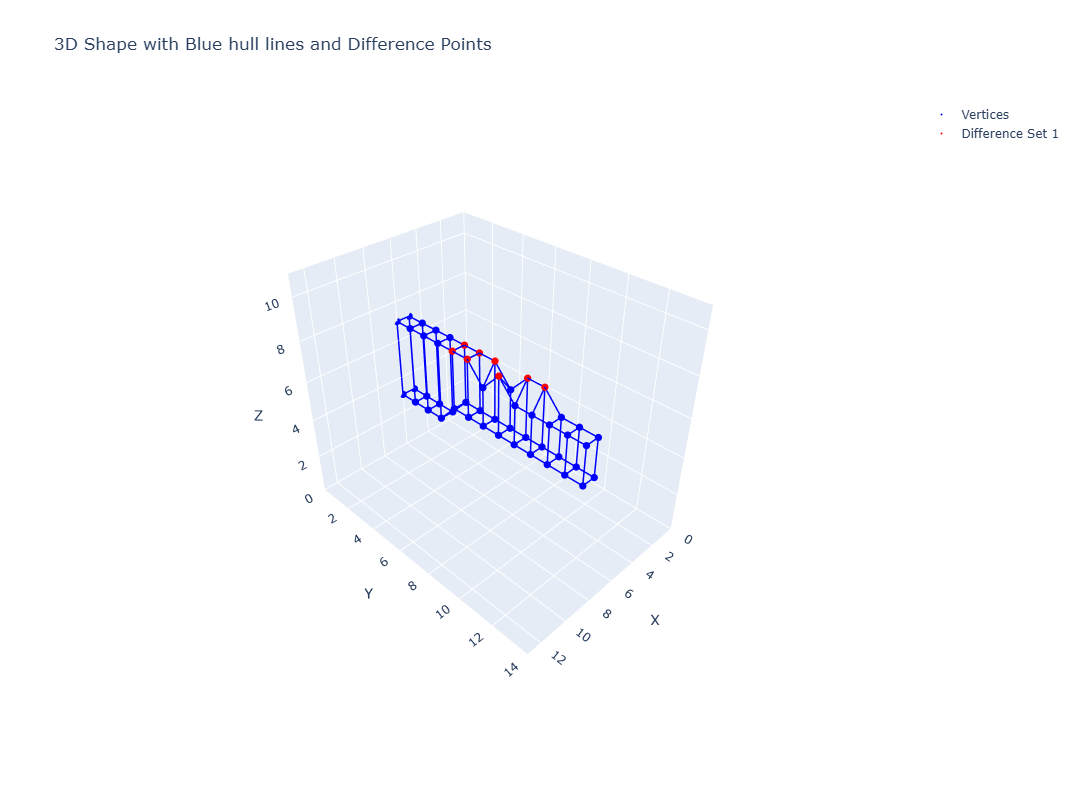

mass force: 20.4
area difference 6
temperature_preservation difference 0.0
lift_force difference 0.0
thrust_force difference 0.09999999999998987
mobility difference 0.09866666666665663
tow_potential 0.9600000000000009
emergence_potential 0
s_value difference 1.0586666666666549


In [25]:
difference_calculator(the_weight_dictionary, aai10, aai20,  0.01, logic_dictionary, 1)

In [26]:
def matrix_symmetry_adjuster(matrix):
    M_flipped=np.flip(matrix, axis=0)
    M_shifted = np.roll(M_flipped, shift=-1, axis=0)
    return M_shifted

In [27]:
def matrix_inclusion_comparison(A, B):
    A = np.array(A)   # your 3D matrix A
    B = np.array(B)   # your 3D matrix B
    
    # Count positions where A == 1 AND B == 1
    matched_ones = np.sum((A == 1) & (B == 1))
    
    # Total number of 1s in B (or A—whichever you define success against)
    total_ones_in_B = np.sum(B == 1)
    
    success_rate = matched_ones / total_ones_in_B if total_ones_in_B > 0 else 0
    
    print("Matched 1s:", matched_ones)
    print("Total 1s in B:", total_ones_in_B)
    print("Success rate:", success_rate)

def inclusion_success_measurer(matrix_of_interest, criteria_matrix,s):
    matrix_inclusion_comparison(matrix_of_interest, criteria_matrix)
    print("temperature_preservation difference",(temperature_preservation(the_weight_dictionary, np.array(matrix_of_interest), s)-temperature_preservation(the_weight_dictionary, np.array(criteria_matrix), s))/temperature_preservation(the_weight_dictionary, np.array(criteria_matrix), s))
    print("lift_force difference",(lift_force(the_weight_dictionary, np.array(matrix_of_interest), s)-lift_force(the_weight_dictionary, np.array(criteria_matrix), s))/lift_force(the_weight_dictionary, np.array(criteria_matrix), s))
    print("thrust_force difference",(thrust_force(the_weight_dictionary, np.array(matrix_of_interest), s)-thrust_force(the_weight_dictionary, np.array(criteria_matrix), s))/thrust_force(the_weight_dictionary, np.array(criteria_matrix), s))
    print("total_number difference",(np.sum(matrix_of_interest)-np.sum(criteria_matrix))/np.sum(criteria_matrix))
    

In [28]:
def inclusion_success_measurer_for_total(matrix_of_interest, criteria_matrix,s):
    Cmatrix_of_interest=matrix_symmetry_adjuster(matrix_of_interest)
    matrix_of_interest = np.array(matrix_of_interest)   # your 3D matrix A
    criteria_matrix = np.array(criteria_matrix)   # your 3D matrix B
    Cmatrix_of_interest = np.array(Cmatrix_of_interest)
    
    matched_ones1 = np.sum((matrix_of_interest == 1) & (criteria_matrix == 1))
    matched_ones2 = np.sum((Cmatrix_of_interest == 1) & (criteria_matrix == 1))
    
    # Total number of 1s in B (or A—whichever you define success against)
    total_ones_in_criteria_matrix = np.sum(criteria_matrix == 1)
    
    success_rate1 = matched_ones1 / total_ones_in_criteria_matrix if total_ones_in_criteria_matrix > 0 else 0
    success_rate2 = matched_ones2 / total_ones_in_criteria_matrix if total_ones_in_criteria_matrix > 0 else 0

    matched_ones=max(matched_ones1, matched_ones2)
    success_rate=max(success_rate1, success_rate2)

    if matched_ones==matched_ones1:
        matrix_of_interest=matrix_of_interest

    if matched_ones==matched_ones2:
        matrix_of_interest=Cmatrix_of_interest

    
    
    return{
        "Matched 1s": matched_ones,
        "Total 1s in criteria_matrix": total_ones_in_criteria_matrix,
        "Success rate": success_rate,
        "temperature_preservation difference":(temperature_preservation(the_weight_dictionary, np.array(matrix_of_interest), s)-temperature_preservation(the_weight_dictionary, np.array(criteria_matrix), s))/temperature_preservation(the_weight_dictionary, np.array(criteria_matrix), s),
        "lift_force difference":(lift_force(the_weight_dictionary, np.array(matrix_of_interest), s)-lift_force(the_weight_dictionary, np.array(criteria_matrix), s))/lift_force(the_weight_dictionary, np.array(criteria_matrix), s),
        "thrust_force difference":(thrust_force(the_weight_dictionary, np.array(matrix_of_interest), s)-thrust_force(the_weight_dictionary, np.array(criteria_matrix), s))/thrust_force(the_weight_dictionary, np.array(criteria_matrix), s),
        "total_number difference":(np.sum(matrix_of_interest)-np.sum(criteria_matrix))/np.sum(criteria_matrix)
         }



In [29]:
inclusion_success_measurer(Matrix1, aai130,0.01)

Matched 1s: 167
Total 1s in B: 214
Success rate: 0.780373831775701
temperature_preservation difference 0.11421066699126987
lift_force difference -0.25442285479445065
thrust_force difference 0.04646484632634223
total_number difference 0.018691588785046728


In [30]:
inclusion_success_measurer(Contrast1, aai130,0.01)

Matched 1s: 133
Total 1s in B: 214
Success rate: 0.6214953271028038
temperature_preservation difference -0.4630986563379341
lift_force difference -0.9999770535798219
thrust_force difference -0.17345996570373357
total_number difference -0.32710280373831774


In [31]:
def matrix_inclusion_comparison_for_excel(A, B):
    A = np.array(A)   # your 3D matrix A
    B = np.array(B)   # your 3D matrix B
    
    # Count positions where A == 1 AND B == 1
    matched_ones = np.sum((A == 1) & (B == 1))
    
    # Total number of 1s in B (or A—whichever you define success against)
    total_ones_in_B = np.sum(B == 1)
    
    success_rate = matched_ones / total_ones_in_B if total_ones_in_B > 0 else 0
    
    return{
        "Matched 1s": matched_ones,
        "Total 1s in B": total_ones_in_B,
        "Success rate": success_rate
         }
def inclusion_success_measurer_for_excel(matrix_of_interest, criteria_matrix,s):
    matrix_inclusion_comparison_for_excel(matrix_of_interest, criteria_matrix)
    return{
        "temperature_preservation difference":(temperature_preservation(the_weight_dictionary, np.array(matrix_of_interest), s)-temperature_preservation(the_weight_dictionary, np.array(criteria_matrix), s))/temperature_preservation(the_weight_dictionary, np.array(criteria_matrix), s),
        "lift_force difference":(lift_force(the_weight_dictionary, np.array(matrix_of_interest), s)-lift_force(the_weight_dictionary, np.array(criteria_matrix), s))/lift_force(the_weight_dictionary, np.array(criteria_matrix), s),
        "thrust_force difference":(thrust_force(the_weight_dictionary, np.array(matrix_of_interest), s)-thrust_force(the_weight_dictionary, np.array(criteria_matrix), s))/thrust_force(the_weight_dictionary, np.array(criteria_matrix), s),
        "total_number difference":(np.sum(matrix_of_interest)-np.sum(criteria_matrix))/np.sum(criteria_matrix)
    }


In [32]:
def inclusion_success_measurer_AIO_for_excel(matrix_of_interest, criteria_matrix,s):
    Cmatrix_of_interest=matrix_symmetry_adjuster(matrix_of_interest)
    matrix_of_interest = np.array(matrix_of_interest)   # your 3D matrix A
    criteria_matrix = np.array(criteria_matrix)   # your 3D matrix B
    Cmatrix_of_interest = np.array(Cmatrix_of_interest)
    
    matched_ones1 = np.sum((matrix_of_interest == 1) & (criteria_matrix == 1))
    matched_ones2 = np.sum((Cmatrix_of_interest == 1) & (criteria_matrix == 1))
    
    # Total number of 1s in B (or A—whichever you define success against)
    total_ones_in_criteria_matrix = np.sum(criteria_matrix == 1)
    
    success_rate1 = matched_ones1 / total_ones_in_criteria_matrix if total_ones_in_criteria_matrix > 0 else 0
    success_rate2 = matched_ones2 / total_ones_in_criteria_matrix if total_ones_in_criteria_matrix > 0 else 0

    matched_ones=max(matched_ones1, matched_ones2)
    success_rate=max(success_rate1, success_rate2)

    if matched_ones==matched_ones1:
        matrix_of_interest=matrix_of_interest

    if matched_ones==matched_ones2:
        matrix_of_interest=Cmatrix_of_interest

    
    
    return{
        "Matched 1s": matched_ones,
        "Total 1s in criteria_matrix": total_ones_in_criteria_matrix,
        "Success rate": success_rate,
        "temperature_preservation difference":(temperature_preservation(the_weight_dictionary, np.array(matrix_of_interest), s)-temperature_preservation(the_weight_dictionary, np.array(criteria_matrix), s))/temperature_preservation(the_weight_dictionary, np.array(criteria_matrix), s),
        "lift_force difference":(lift_force(the_weight_dictionary, np.array(matrix_of_interest), s)-lift_force(the_weight_dictionary, np.array(criteria_matrix), s))/lift_force(the_weight_dictionary, np.array(criteria_matrix), s),
        "lift_force":lift_force(the_weight_dictionary, np.array(matrix_of_interest), s),
        "thrust_force difference":(thrust_force(the_weight_dictionary, np.array(matrix_of_interest), s)-thrust_force(the_weight_dictionary, np.array(criteria_matrix), s))/thrust_force(the_weight_dictionary, np.array(criteria_matrix), s),
        "total_number difference":(np.sum(matrix_of_interest)-np.sum(criteria_matrix))/np.sum(criteria_matrix)
         }



In [33]:
Matrices = [globals()[f"Matrix{i}"] for i in range(1, 31)]

In [34]:
Contrasts = [globals()[f"Contrast{i}"] for i in range(1, 31)]

In [35]:
results = []

for i, Matrix in enumerate(Matrices, start=1):
    
    analysis = inclusion_success_measurer_AIO_for_excel(Matrix,aai130,0.01)
    results.append(analysis)
    analysis["Matrix_id"] = i


import pandas as pd

df = pd.DataFrame(results)
df.to_excel("matrix_analysis_AIO.xlsx", index=False)

In [36]:
results = []

for i, Contrast in enumerate(Contrasts, start=1):
    
    analysis = inclusion_success_measurer_AIO_for_excel(Contrast,aai130,0.01)
    results.append(analysis)
    analysis["Matrix_id"] = i


import pandas as pd

df = pd.DataFrame(results)
df.to_excel("contrast_analysis_AIO.xlsx", index=False)